# Method Visualization — Paper Figures

| # | Figura | Descrizione |
|---|--------|-------------|
| A | `fig_multiclass_pruning.pdf` | Griglia classi × keep ratio: mostra dove il forecaster taglia |
| B | `fig_saliency_vs_forecaster.pdf` | Saliency map (Gradient×Input) vs forecaster scores vs CLS attn |
| C | `fig_single_best.pdf` | Figura singola di qualità: originale → attn L24 → pruning crescente |

In [89]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from PIL import Image as PILImage
import timm, sys, gc
from pathlib import Path
from tqdm.auto import tqdm
from peft import LoraConfig
from peft.tuners.lora import LoraModel
import torchvision.transforms as T

sys.path.append("..")
from src.dataset import HistologicalImageDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [90]:
DATASET_NAME = "BREAKHIS"
CKPT_BASE    = Path(f"/data/checkpoints-Attention-Pruning/{DATASET_NAME}")

CFG = dict(
    data_dir        = f"/data/{DATASET_NAME}",
    img_size        = 224,
    patch_size      = 16,
    grid_h          = 14,
    grid_w          = 14,
    n_patches       = 196,
    prune_layer     = 2,
    keep_ratios     = [0.1, 0.2, 0.3, 0.5],   # per fig A e C
    n_per_class     = 1,                        # immagini per classe in fig A
    ckpt_classifier = CKPT_BASE / "uni_finetuned"    / "best_model.pt",
    ckpt_pruned_ft  = CKPT_BASE / "pruned_finetuned" / "best_prune_layer2_keep10.pt",
    ckpt_forecaster = CKPT_BASE / "forecaster"       / "forecaster_src02_tgt23.pt",
    out_dir         = Path(f"results/{DATASET_NAME}/method_viz"),
    # Colori
    color_fc        = "#e63946",   # rosso — Forecaster
    color_cls       = "#457b9d",   # blu   — CLS Attn L2
    color_sal       = "#2d6a4f",   # verde — Saliency
)
CFG["out_dir"].mkdir(parents=True, exist_ok=True)
print(f"Output → {CFG['out_dir']}")

Output → results/BREAKHIS/method_viz


In [91]:
eval_tf = T.Compose([
    T.Resize((CFG["img_size"], CFG["img_size"])),
    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])
raw_tf = T.Compose([T.Resize((CFG["img_size"], CFG["img_size"]))])

test_ds     = HistologicalImageDataset(f"{CFG['data_dir']}/test", transform=eval_tf)
test_ds_raw = HistologicalImageDataset(f"{CFG['data_dir']}/test", transform=raw_tf)
CLASS_NAMES = test_ds.class_names
N_CLASSES   = len(CLASS_NAMES)
print(f"Classi ({N_CLASSES}): {CLASS_NAMES}")

Loading from /data/BREAKHIS/test...
Loaded 6833 samples, 8 classes
Class distribution:
  adenosis: 540 (7.9%)
  fibroadenoma: 693 (10.1%)
  phyllodes_tumor: 423 (6.2%)
  tubular_adenoma: 602 (8.8%)
  ductal_carcinoma: 2769 (40.5%)
  lobular_carcinoma: 602 (8.8%)
  mucinous_carcinoma: 757 (11.1%)
  papillary_carcinoma: 447 (6.5%)
Loading from /data/BREAKHIS/test...
Loaded 6833 samples, 8 classes
Class distribution:
  adenosis: 540 (7.9%)
  fibroadenoma: 693 (10.1%)
  phyllodes_tumor: 423 (6.2%)
  tubular_adenoma: 602 (8.8%)
  ductal_carcinoma: 2769 (40.5%)
  lobular_carcinoma: 602 (8.8%)
  mucinous_carcinoma: 757 (11.1%)
  papillary_carcinoma: 447 (6.5%)
Classi (8): ['adenosis', 'fibroadenoma', 'phyllodes_tumor', 'tubular_adenoma', 'ductal_carcinoma', 'lobular_carcinoma', 'mucinous_carcinoma', 'papillary_carcinoma']


In [92]:
class AttentionForecaster(nn.Module):
    def __init__(self, embed_dim=1024, hidden=256, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj  = nn.Linear(embed_dim, hidden)
        self.cls_query   = nn.Parameter(torch.randn(1, 1, hidden) * 0.02)
        self.self_attn   = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=hidden, nhead=n_heads, dim_feedforward=hidden*2,
                dropout=dropout, batch_first=True, norm_first=True)
            for _ in range(n_layers)])
        self.cross_attn  = nn.ModuleList([
            nn.MultiheadAttention(hidden, n_heads, dropout=dropout, batch_first=True)
            for _ in range(n_layers)])
        self.cross_norms = nn.ModuleList([nn.LayerNorm(hidden) for _ in range(n_layers)])
        self.norm        = nn.LayerNorm(hidden)
        self.score_head  = nn.Sequential(
            nn.Linear(hidden*2, 128), nn.GELU(), nn.Dropout(dropout), nn.Linear(128, 1))

    def forward(self, x):
        B, N, _ = x.shape
        x = self.input_proj(x)
        for sa in self.self_attn: x = sa(x)
        cls = self.cls_query.expand(B, -1, -1)
        for ca, norm in zip(self.cross_attn, self.cross_norms):
            cls_out, _ = ca(cls, x, x)
            cls = norm(cls + cls_out)
        x_norm  = self.norm(x)
        cls_exp = cls.expand(-1, N, -1)
        return self.score_head(torch.cat([x_norm, cls_exp], dim=-1)).squeeze(-1).softmax(-1)


class UNILoRAClassifier(nn.Module):
    def __init__(self, n_classes, dropout=0.1):
        super().__init__()
        backbone = timm.create_model(
            "hf-hub:MahmoodLab/uni", pretrained=True,
            init_values=1e-5, dynamic_img_size=True, num_classes=0)
        lora_cfg = LoraConfig(r=8, lora_alpha=32,
            target_modules=["qkv","proj","fc1","fc2"],
            lora_dropout=0.1, bias="none")
        self.backbone = LoraModel(backbone, lora_cfg, adapter_name="default")
        self.head     = nn.Sequential(
            nn.LayerNorm(1024), nn.Dropout(dropout), nn.Linear(1024, n_classes))
    def forward(self, x):
        return self.head(self.backbone(x))


def load_ckpt(model, path, strict=False):
    state = torch.load(Path(path), map_location="cpu")
    if "state_dict" in state: state = state["state_dict"]
    state = {k.replace("module.", ""): v for k, v in state.items()}
    miss, unex = model.load_state_dict(state, strict=strict)
    if miss:  print(f"  [WARN] {len(miss)} missing keys")
    if unex:  print(f"  [WARN] {len(unex)} unexpected keys")
    return model

def freeze(model):
    model.eval()
    for p in model.parameters(): p.requires_grad_(False)
    return model

print("Loading classifier (ckpt_pruned_ft)...")
clf = freeze(load_ckpt(UNILoRAClassifier(N_CLASSES).to(device),
                        CFG["ckpt_pruned_ft"], strict=False))
print("Loading forecaster...")
forecaster = freeze(load_ckpt(AttentionForecaster().to(device),
                               CFG["ckpt_forecaster"], strict=True))
vit = clf.backbone.model
print(f"ViT: {len(vit.blocks)} blocks, embed_dim={vit.embed_dim}")

Loading classifier (ckpt_pruned_ft)...
  [WARN] 45 unexpected keys
Loading forecaster...
ViT: 24 blocks, embed_dim=1024


In [93]:
# ─────────────────────────────────────────────────────────────────────────
# Core extraction: per una singola immagine (1,C,H,W) ritorna tutti i
# segnali necessari alle 3 figure in un'unica forward pass.
# ─────────────────────────────────────────────────────────────────────────

@torch.no_grad()
def extract_all(img_norm_t):
    """
    Returns dict:
      fc_scores   : (196,)  forecaster probability scores
      cls2_scores : (196,)  CLS→patch attention at layer 2 (mean heads)
      last_attn   : (196,)  CLS→patch attention at layer 23 (mean heads, full seq)
      logits      : (N_cls,)
      x_norm1     : (196, D)  patch embeddings after norm1 at layer 2
    """
    x = img_norm_t.to(device)
    B = 1
    pl = CFG["prune_layer"]

    x = vit.patch_embed(x)
    x = vit._pos_embed(x)
    x = vit.patch_drop(x)
    x = vit.norm_pre(x)

    for i in range(pl):
        x = vit.blocks[i](x)

    # ── Layer 2 ──────────────────────────────────────────────────────────
    blk = vit.blocks[pl]
    N, C = x.shape[1], x.shape[2]
    x_n1 = blk.norm1(x)                          # (1, 197, D)

    fc_scores = forecaster(x_n1[:, 1:])           # (1, 196)

    # CLS attn at layer 2
    qkv = blk.attn.qkv(x_n1).reshape(B, N, 3, blk.attn.num_heads, -1).permute(2,0,3,1,4)
    q, k, _ = qkv.unbind(0)
    q, k = blk.attn.q_norm(q), blk.attn.k_norm(k)
    attn2 = (q @ k.transpose(-2,-1) * blk.attn.scale).softmax(-1)  # (1, H, N, N)
    cls2_scores = attn2[:, :, 0, 1:].mean(1)      # (1, 196)

    x = vit.blocks[pl](x)   # complete block 2

    # ── Layers 3→23 ──────────────────────────────────────────────────────
    last_attn_scores = None
    for i in range(pl + 1, len(vit.blocks)):
        if i == len(vit.blocks) - 1:
            blk_l = vit.blocks[i]
            xl    = blk_l.norm1(x)
            qkvl  = blk_l.attn.qkv(xl).reshape(B, x.shape[1], 3, blk_l.attn.num_heads, -1).permute(2,0,3,1,4)
            ql, kl, _ = qkvl.unbind(0)
            ql, kl = blk_l.attn.q_norm(ql), blk_l.attn.k_norm(kl)
            attnl  = (ql @ kl.transpose(-2,-1) * blk_l.attn.scale).softmax(-1)
            last_attn_scores = attnl[:, :, 0, 1:].mean(1)   # (1, 196)
        x = vit.blocks[i](x)

    x = vit.norm(x)
    logits = clf.head(x[:, 0])   # (1, N_cls)

    return dict(
        fc_scores   = fc_scores[0].cpu(),
        cls2_scores = cls2_scores[0].cpu(),
        last_attn   = last_attn_scores[0].cpu(),
        logits      = logits[0].cpu(),
        x_norm1     = x_n1[0, 1:].cpu(),
    )


# ── Gradient × Input saliency ─────────────────────────────────────────────
def compute_gradient_input_saliency(img_norm_t, target_class):
    """
    Gradient × Input sul pixel space: ||grad(logit_c) wrt input|| * |input|.
    Ritorna (196,) scores per patch — aggregati come media pixel nel patch.
    """
    inp = img_norm_t.to(device).requires_grad_(True)  # (1,3,H,W)

    # Forward completo con grad
    logits = clf(inp)                                  # (1, N_cls)
    score  = logits[0, target_class]
    score.backward()

    # grad shape: (1, 3, H, W)
    grad  = inp.grad.detach().cpu()                    # (1, 3, 224, 224)
    inp_d = inp.detach().cpu()

    # Gradient × Input (GI) — saliency nel pixel space
    gi = (grad * inp_d).abs().sum(dim=1, keepdim=True)  # (1, 1, 224, 224)
    gi = gi[0, 0]  # (224, 224)

    # Aggrega per patch 16×16 → (196,)
    P = CFG["patch_size"]
    H_g, W_g = CFG["grid_h"], CFG["grid_w"]
    patch_scores = torch.zeros(H_g * W_g)
    for r in range(H_g):
        for c in range(W_g):
            patch_scores[r * W_g + c] = gi[r*P:(r+1)*P, c*P:(c+1)*P].mean()

    inp.grad = None
    return patch_scores  # (196,)


print("Extraction functions defined.")

Extraction functions defined.


In [94]:
# ─────────────────────────────────────────────────────────────────────────
# Utility: visualizzazione patch
# ─────────────────────────────────────────────────────────────────────────
H_G = CFG["grid_h"]   # 14
W_G = CFG["grid_w"]   # 14
P   = CFG["patch_size"]  # 16


def scores_to_mask(scores_1d, keep_ratio):
    k = max(1, int(len(scores_1d) * keep_ratio))
    mask = torch.zeros(len(scores_1d), dtype=torch.bool)
    mask[scores_1d.topk(k).indices] = True
    return mask


def apply_mask_to_img(img_np, mask_1d, alpha_dropped=0.82):
    """img_np: (H,W,3) float [0,1]. Patch scartati → molto scuri."""
    out = img_np.copy()
    m2d = mask_1d.reshape(H_G, W_G).numpy()
    for r in range(H_G):
        for c in range(W_G):
            if not m2d[r, c]:
                out[r*P:(r+1)*P, c*P:(c+1)*P] *= (1 - alpha_dropped)
    return out


def scores_to_overlay(scores_1d, img_np, cmap="inferno", alpha=0.6):
    """Heatmap continua sovrapposta all'immagine."""
    heat = scores_1d.reshape(H_G, W_G).numpy()
    heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)
    heat_up = np.array(
        PILImage.fromarray((heat * 255).astype(np.uint8)).resize(
            (CFG["img_size"], CFG["img_size"]), resample=PILImage.BILINEAR)
    ) / 255.0
    cm = plt.get_cmap(cmap)
    heat_rgba = cm(heat_up)[:, :, :3]   # (H, W, 3)
    return img_np * (1 - alpha) + heat_rgba * alpha


def ax_pruned(ax, img_np, mask_1d, label, color, fontsize=7.5):
    """Pannello standard: immagine mascherata con titolo."""
    ax.imshow(apply_mask_to_img(img_np, mask_1d), interpolation="bilinear")
    k = mask_1d.sum().item()
    ax.set_title(label, fontsize=fontsize, color=color,
                 fontweight="bold", pad=2)
    ax.set_xlabel(f"{k}/196 tokens", fontsize=6.5, labelpad=1)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_edgecolor(color); sp.set_linewidth(1.2)


def ax_heatmap(ax, img_np, scores_1d, label, color, cmap="inferno", fontsize=7.5):
    ax.imshow(scores_to_overlay(scores_1d, img_np, cmap=cmap), interpolation="bilinear")
    ax.set_title(label, fontsize=fontsize, color=color, fontweight="bold", pad=2)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_edgecolor(color); sp.set_linewidth(1.2)


print("Utility functions defined.")

Utility functions defined.


---
## Fig. A — Pruning multi-classe a keep ratio crescenti

**Struttura**: 8 righe (una per classe) × 5 colonne (originale + 4 keep ratio).  
Per ogni immagine scegliamo la più alta confidenza correttamente classificata.

In [95]:
# ── Scan: trova il campione migliore per ciascuna classe ─────────────────
print("Scanning test set — best sample per class...")

best_per_class = {}   # class_idx → dict(img_np, fc_scores, cls2_scores, last_attn, conf, label)
conf_per_class = {c: -1.0 for c in range(N_CLASSES)}

for idx in tqdm(range(len(test_ds))):
    lbl = test_ds.labels[idx]

    img_n, _ = test_ds[idx]
    out = extract_all(img_n.unsqueeze(0))

    probs = out["logits"].softmax(-1)
    pred  = probs.argmax().item()
    conf  = probs.max().item()

    if pred == lbl and conf > conf_per_class[lbl]:
        img_r, _ = test_ds_raw[idx]
        conf_per_class[lbl] = conf
        best_per_class[lbl] = dict(
            img_np      = img_r.permute(1,2,0).numpy().clip(0,1),
            fc_scores   = out["fc_scores"],
            cls2_scores = out["cls2_scores"],
            last_attn   = out["last_attn"],
            conf        = conf,
            label       = lbl,
        )

    if len(best_per_class) == N_CLASSES and all(conf_per_class[c] > 0.8 for c in range(N_CLASSES)):
        break   # early stop se tutti superano 0.80

print("\nBest per class:")
for c in range(N_CLASSES):
    if c in best_per_class:
        print(f"  {CLASS_NAMES[c]:22s}  conf={conf_per_class[c]:.4f}")
    else:
        print(f"  {CLASS_NAMES[c]:22s}  NOT FOUND")

Scanning test set — best sample per class...


  0%|          | 0/6833 [00:00<?, ?it/s]


Best per class:
  adenosis                conf=0.8864
  fibroadenoma            conf=0.9232
  phyllodes_tumor         conf=0.9132
  tubular_adenoma         conf=0.9112
  ductal_carcinoma        conf=0.9233
  lobular_carcinoma       conf=0.9286
  mucinous_carcinoma      conf=0.9184
  papillary_carcinoma     conf=0.9150


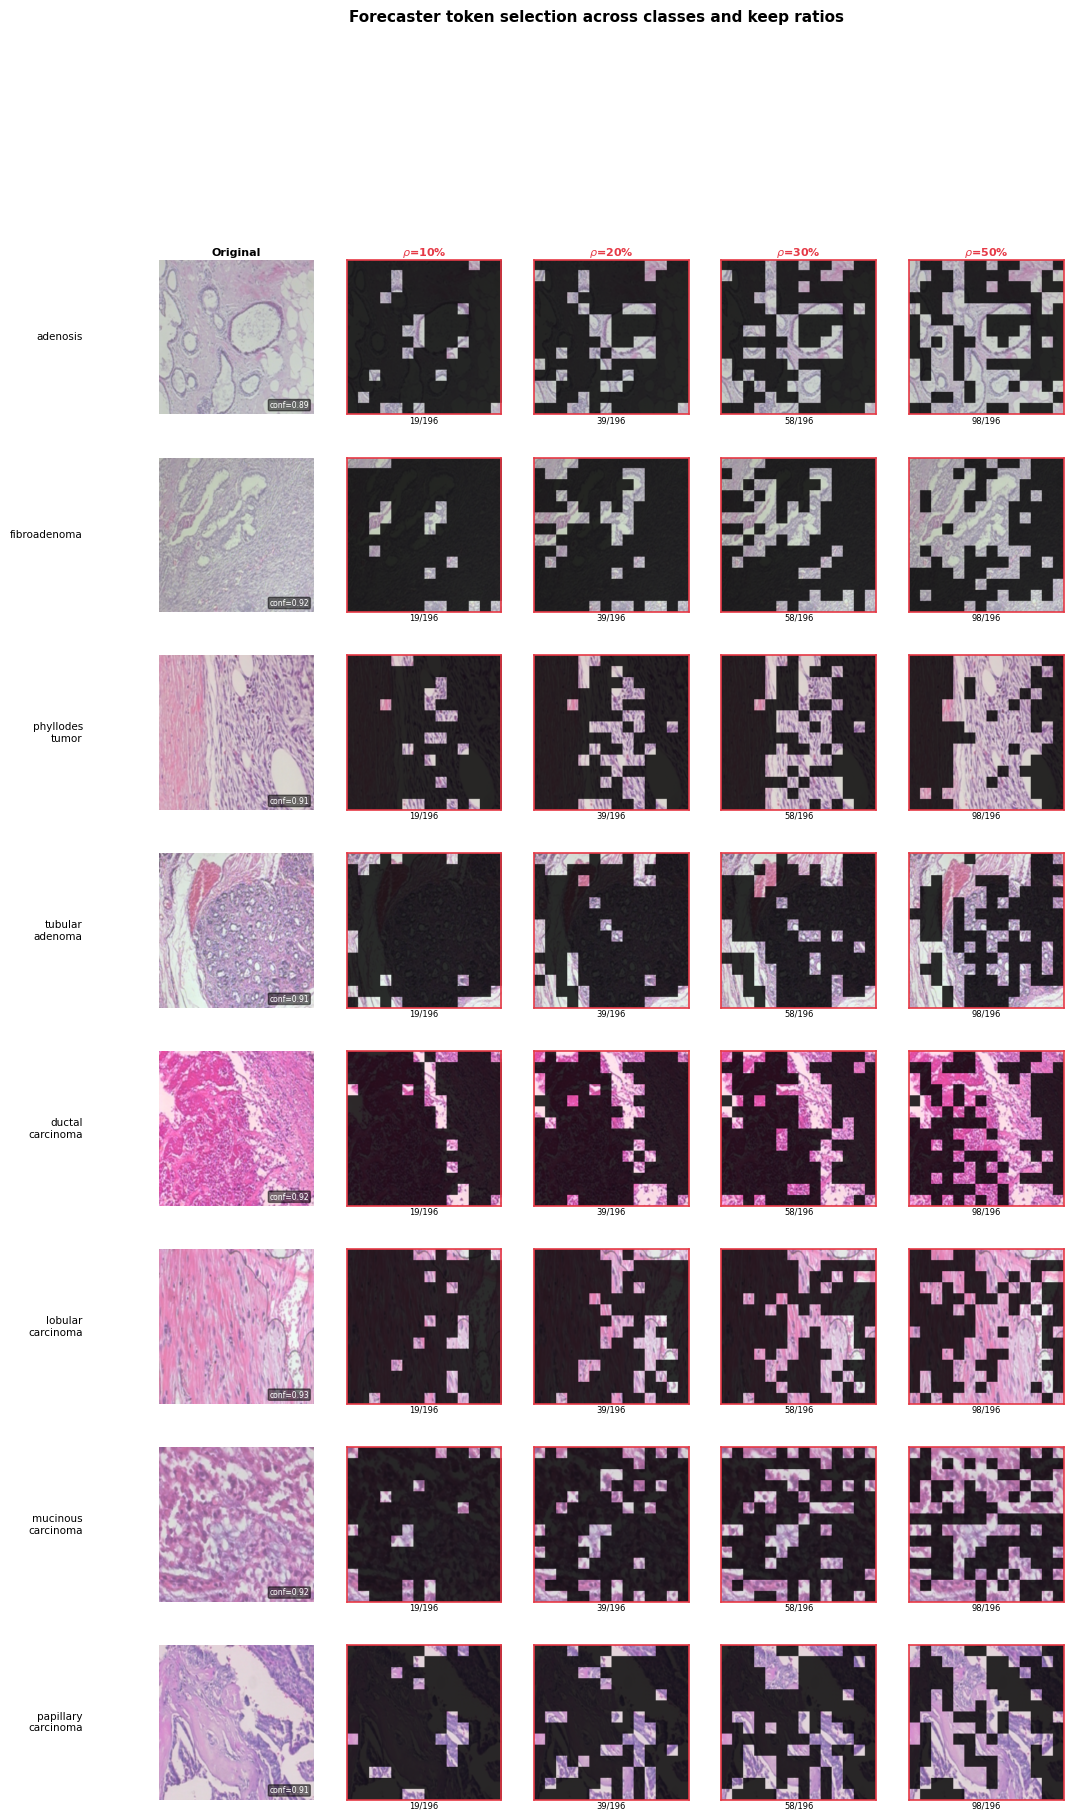

Saved → results/BREAKHIS/method_viz/fig_multiclass_pruning.pdf


In [96]:
KR_LIST   = CFG["keep_ratios"]   # [0.1, 0.2, 0.3, 0.5]
N_COLS    = 1 + len(KR_LIST)     # orig + 4 keep ratios
N_ROWS    = N_CLASSES            # 8
COLOR_FC  = CFG["color_fc"]

fig_A, axes_A = plt.subplots(
    N_ROWS, N_COLS,
    figsize=(2.4 * N_COLS, 2.5 * N_ROWS),
    gridspec_kw=dict(wspace=0.04, hspace=0.28),
)

# Etichette colonne nella prima riga
col_labels = ["Original"] + [f"$\\rho$={kr:.0%}" for kr in KR_LIST]

for row, cls_idx in enumerate(range(N_CLASSES)):
    cand = best_per_class.get(cls_idx, None)

    for col in range(N_COLS):
        ax = axes_A[row, col]

        if cand is None:
            ax.set_visible(False)
            continue

        if col == 0:
            # Immagine originale
            ax.imshow(cand["img_np"], interpolation="bilinear")
            ax.set_xticks([]); ax.set_yticks([])
            for sp in ax.spines.values(): sp.set_visible(False)
            if row == 0:
                ax.set_title(col_labels[0], fontsize=8, fontweight="bold", pad=3)
            # Etichetta classe sulla sinistra
            cls_label = CLASS_NAMES[cls_idx].replace("_", "\n")
            ax.set_ylabel(cls_label, fontsize=7.5, rotation=0,
                          labelpad=55, va="center", ha="right")
        else:
            kr   = KR_LIST[col - 1]
            mask = scores_to_mask(cand["fc_scores"], kr)
            ax_pruned(ax, cand["img_np"], mask,
                      label=col_labels[col] if row == 0 else "",
                      color=COLOR_FC, fontsize=8)
            ax.set_xlabel(f"{mask.sum().item()}/196", fontsize=6, labelpad=1)

# Nota confidenza nell'angolo in basso
for row, cls_idx in enumerate(range(N_CLASSES)):
    if cls_idx in best_per_class:
        axes_A[row, 0].text(
            0.97, 0.03,
            f"conf={best_per_class[cls_idx]['conf']:.2f}",
            transform=axes_A[row, 0].transAxes,
            fontsize=5.5, color="white", ha="right", va="bottom",
            bbox=dict(boxstyle="round,pad=0.15", fc="black", alpha=0.5)
        )

fig_A.suptitle(
    "Forecaster token selection across classes and keep ratios",
    fontsize=11, fontweight="bold", y=1.005
)

out_A = CFG["out_dir"] / "fig_multiclass_pruning.pdf"
fig_A.savefig(out_A, dpi=200, bbox_inches="tight")
fig_A.savefig(str(out_A).replace(".pdf", ".png"), dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {out_A}")

---
## Fig. B — Saliency Map vs Forecaster vs CLS Attention

Confronto qualitativo tra tre modi diversi di misurare l'importanza dei patch:

| Metodo | Cosa misura | Dove viene calcolato |
|--------|------------|----------------------|
| **Gradient × Input** | `‖∂ logit_c / ∂ input‖ × ‖input‖` aggregato per patch | Pixel space — l'intero modello |
| **Forecaster** | Score predetto dalla rete ausiliaria | Layer 2 embedding space |
| **CLS Attn L2** | Attenzione CLS→patch al layer 2 | Layer 2 attention matrix |
| **CLS Attn L24** | Attenzione CLS→patch all'ultimo layer | Layer 24 attention matrix |

Usiamo la classe scelta con confidenza più alta tra tutte le classi.

In [97]:
# Scegli l'immagine con confidenza massima assoluta tra tutti i campioni trovati
best_cls = max(best_per_class, key=lambda c: conf_per_class[c])
cand_B   = best_per_class[best_cls]
print(f"Fig B — using class '{CLASS_NAMES[best_cls]}'  conf={cand_B['conf']:.4f}")

# Ricalcola su immagine normalizzata (serve per grad)
# Trova l'indice nel dataset
b_idx = None
for i in range(len(test_ds)):
    if test_ds.labels[i] == best_cls:
        img_n, _ = test_ds[i]
        out = extract_all(img_n.unsqueeze(0))
        conf_i = out["logits"].softmax(-1).max().item()
        if abs(conf_i - cand_B["conf"]) < 1e-4:
            b_idx = i
            break

print(f"Found at dataset index: {b_idx}")
img_n_B, _ = test_ds[b_idx]
img_np_B   = cand_B["img_np"]

# Gradient × Input saliency
print("Computing Gradient × Input saliency...")
# Ri-abilita grad sul classificatore per il backward
for p in clf.parameters(): p.requires_grad_(True)
clf.train()   # disabilita dropout deterministico
sal_scores = compute_gradient_input_saliency(
    img_n_B.unsqueeze(0), target_class=best_cls)
clf.eval()
for p in clf.parameters(): p.requires_grad_(False)

print(f"Saliency — min={sal_scores.min():.4f}  max={sal_scores.max():.4f}")

Fig B — using class 'lobular_carcinoma'  conf=0.9286


Found at dataset index: 39
Computing Gradient × Input saliency...
Saliency — min=0.0005  max=0.0033


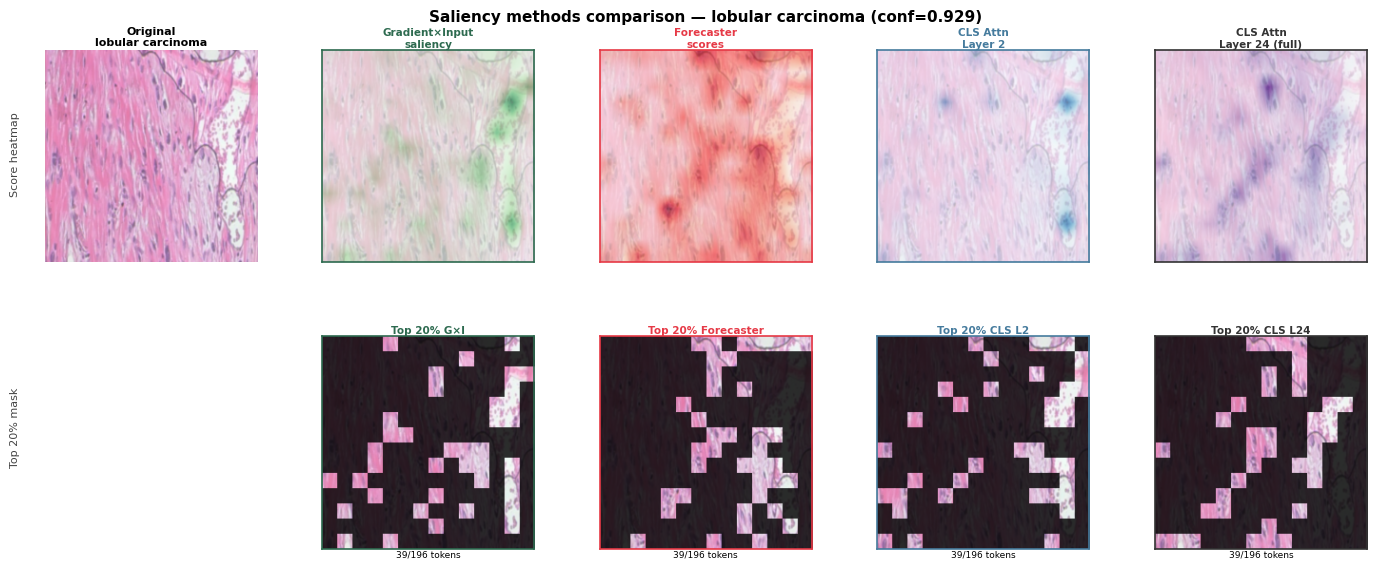

Saved → results/BREAKHIS/method_viz/fig_saliency_vs_forecaster.pdf


In [98]:
COLOR_FC  = CFG["color_fc"]
COLOR_CLS = CFG["color_cls"]
COLOR_SAL = CFG["color_sal"]

fc_s   = cand_B["fc_scores"]
cls2_s = cand_B["cls2_scores"]
last_s = cand_B["last_attn"]

# Layout: 2 righe × 5 colonne
# Riga 0: Originale | GI saliency | Forecaster | CLS L2 | CLS L24
# Riga 1:     —     | Forecaster kr=20% | GI top-20% | CLS L2 kr=20% | CLS L24 kr=20%
fig_B = plt.figure(figsize=(14, 5.8))
gs_B  = gridspec.GridSpec(2, 5, figure=fig_B,
                           wspace=0.06, hspace=0.35,
                           left=0.01, right=0.99, top=0.90, bottom=0.04)

KR_SHOW = 0.2   # keep ratio per la riga di maschere binarie

# ── Riga 0: heatmap continue ─────────────────────────────────────────────
ax00 = fig_B.add_subplot(gs_B[0, 0])
ax00.imshow(img_np_B, interpolation="bilinear")
ax00.set_title(f"Original\n{CLASS_NAMES[best_cls].replace('_',' ')}",
               fontsize=8, fontweight="bold", pad=3)
ax00.set_xticks([]); ax00.set_yticks([])
for sp in ax00.spines.values(): sp.set_visible(False)

ax01 = fig_B.add_subplot(gs_B[0, 1])
ax_heatmap(ax01, img_np_B, sal_scores,
           "Gradient×Input\nsaliency", COLOR_SAL, cmap="Greens")

ax02 = fig_B.add_subplot(gs_B[0, 2])
ax_heatmap(ax02, img_np_B, fc_s,
           "Forecaster\nscores", COLOR_FC, cmap="Reds")

ax03 = fig_B.add_subplot(gs_B[0, 3])
ax_heatmap(ax03, img_np_B, cls2_s,
           "CLS Attn\nLayer 2", COLOR_CLS, cmap="Blues")

ax04 = fig_B.add_subplot(gs_B[0, 4])
ax_heatmap(ax04, img_np_B, last_s,
           "CLS Attn\nLayer 24 (full)", "#333333", cmap="Purples")

# ── Riga 1: maschere binarie top-KR_SHOW ──────────────────────────────────
fig_B.add_subplot(gs_B[1, 0]).set_visible(False)   # spazio vuoto

ax11 = fig_B.add_subplot(gs_B[1, 1])
ax_pruned(ax11, img_np_B, scores_to_mask(sal_scores, KR_SHOW),
          f"Top {KR_SHOW:.0%} G×I", COLOR_SAL)

ax12 = fig_B.add_subplot(gs_B[1, 2])
ax_pruned(ax12, img_np_B, scores_to_mask(fc_s, KR_SHOW),
          f"Top {KR_SHOW:.0%} Forecaster", COLOR_FC)

ax13 = fig_B.add_subplot(gs_B[1, 3])
ax_pruned(ax13, img_np_B, scores_to_mask(cls2_s, KR_SHOW),
          f"Top {KR_SHOW:.0%} CLS L2", COLOR_CLS)

ax14 = fig_B.add_subplot(gs_B[1, 4])
ax_pruned(ax14, img_np_B, scores_to_mask(last_s, KR_SHOW),
          f"Top {KR_SHOW:.0%} CLS L24", "#333333")

# Etichette riga
fig_B.text(0.003, 0.72, "Score heatmap",
           fontsize=8, va="center", rotation=90, color="#444")
fig_B.text(0.003, 0.25, f"Top {KR_SHOW:.0%} mask",
           fontsize=8, va="center", rotation=90, color="#444")

fig_B.suptitle(
    f"Saliency methods comparison — {CLASS_NAMES[best_cls].replace('_', ' ')} "
    f"(conf={cand_B['conf']:.3f})",
    fontsize=11, fontweight="bold", y=0.97
)

out_B = CFG["out_dir"] / "fig_saliency_vs_forecaster.pdf"
fig_B.savefig(out_B, dpi=200, bbox_inches="tight")
fig_B.savefig(str(out_B).replace(".pdf", ".png"), dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {out_B}")

---
## Fig. C — Figura singola di qualità per il paper

Immagine singola (quella con confidenza più alta), layout compatto per una colonna di paper:

```
[ Original ] [ Attn L24 ] [ ρ=10% ] [ ρ=20% ] [ ρ=30% ] [ ρ=50% ]
```

Sotto ogni pannello pruned: barra orizzontale proporzionale alla frazione di token mantenuti.

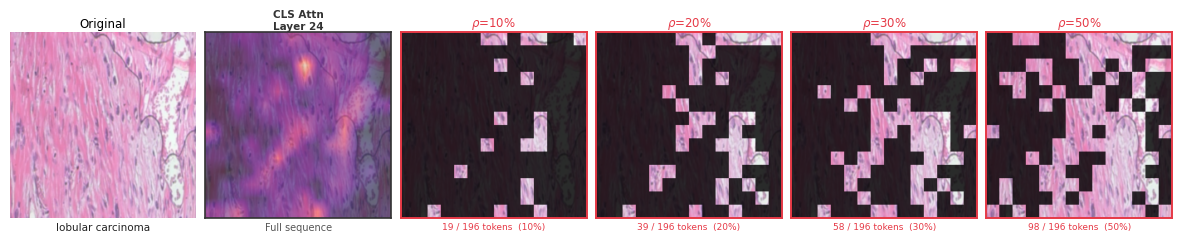

Saved → results/BREAKHIS/method_viz/fig_single_best.pdf


In [99]:
fc_s   = cand_B["fc_scores"]
last_s = cand_B["last_attn"]
KR_C   = [0.1, 0.2, 0.3, 0.5]

n_panels = 2 + len(KR_C)   # orig + attn + 4 keep ratios
fig_C, axes_C = plt.subplots(
    1, n_panels,
    figsize=(2.5 * n_panels, 3.2),
    gridspec_kw=dict(wspace=0.05)
)

# Pannello 0: originale
axes_C[0].imshow(img_np_B, interpolation="bilinear")
axes_C[0].set_title("Original", fontsize=8.5,  pad=3)
axes_C[0].set_xticks([]); axes_C[0].set_yticks([])
for sp in axes_C[0].spines.values(): sp.set_visible(False)
# Etichetta classe
axes_C[0].set_xlabel(
    CLASS_NAMES[best_cls].replace("_", " "),
    fontsize=7.5, labelpad=3, color="#222"
)

# Pannello 1: CLS attention L24 (heatmap continua)
ax_heatmap(axes_C[1], img_np_B, last_s,
           "CLS Attn\nLayer 24", "#333333", cmap="magma")
axes_C[1].set_xlabel("Full sequence", fontsize=7, labelpad=3, color="#555")

# Pannelli 2…5: pruning forecaster
for j, kr in enumerate(KR_C):
    ax = axes_C[2 + j]
    mask = scores_to_mask(fc_s, kr)
    ax.imshow(apply_mask_to_img(img_np_B, mask), interpolation="bilinear")
    ax.set_title(f"$\\rho$={kr:.0%}", fontsize=8.5,
                 color=COLOR_FC, pad=3)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_edgecolor(COLOR_FC); sp.set_linewidth(1.4)

    # Barra token mantenuti
    k = mask.sum().item()
    ax.set_xlabel(f"{k} / 196 tokens  ({kr:.0%})",
                  fontsize=6.5, labelpad=3, color=COLOR_FC)

# # Freccia con etichetta "Forecaster"
# fig_C.text(
#     0.5, -0.04,
#     "← Forecaster token selection →",
#     ha="center", va="center", fontsize=9,
#     color=COLOR_FC
# )

out_C = CFG["out_dir"] / "fig_single_best.pdf"
fig_C.savefig(out_C, dpi=200, bbox_inches="tight")
fig_C.savefig(str(out_C).replace(".pdf", ".png"), dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {out_C}")

---
## Fig. D — Immagine con massima similarità Forecaster ↔ Saliency

Cerca nell'intero test set l'immagine in cui la **Spearman rank correlation**
tra `fc_scores` (196,) e `sal_scores` (196,) è massima.

La Spearman ρ misura la concordanza dei *ranking* dei 196 patch indipendentemente
dalla scala assoluta dei due segnali — è la metrica corretta per confrontare
distribuzioni di score eterogenee.

Scan su 50 campioni per classe (400 totali) per costo computazionale ragionevole
(ogni saliency richiede un backward pass completo).

In [100]:
from scipy.stats import spearmanr
import random

N_PER_CLASS_SAL = 50   # campioni per classe — bilancia qualità vs tempo

# Indici stratificati: N_PER_CLASS_SAL per ogni classe
random.seed(42)
class_indices = {c: [] for c in range(N_CLASSES)}
for idx in range(len(test_ds)):
    class_indices[test_ds.labels[idx]].append(idx)

scan_indices = []
for c in range(N_CLASSES):
    pool = class_indices[c]
    chosen = random.sample(pool, min(N_PER_CLASS_SAL, len(pool)))
    scan_indices.extend(chosen)

print(f"Scanning {len(scan_indices)} images ({N_PER_CLASS_SAL} per class)...")
print("Each image requires 1 forward + 1 backward pass.")

# Abilita grad per il backward
for p in clf.parameters(): p.requires_grad_(True)
clf.eval()  # mantieni eval per BN/dropout ma consenti grad

sal_records = []  # list of dicts
best_sal = dict(spearman=-2.0)

for idx in tqdm(scan_indices):
    lbl = test_ds.labels[idx]
    img_n, _ = test_ds[idx]
    img_n_t  = img_n.unsqueeze(0)

    # Forward no-grad: fc_scores
    out = extract_all(img_n_t)
    probs = out["logits"].softmax(-1)
    pred  = probs.argmax().item()
    conf  = probs.max().item()

    if pred != lbl:   # salta campioni errati
        continue

    # Saliency (backward)
    sal = compute_gradient_input_saliency(img_n_t, target_class=lbl)

    # Spearman rank correlation fc_scores vs saliency
    rho, pval = spearmanr(out["fc_scores"].numpy(), sal.numpy())

    sal_records.append(dict(
        idx=idx, label=lbl, conf=conf, spearman=rho, pval=pval
    ))

    if rho > best_sal["spearman"]:
        img_r, _ = test_ds_raw[idx]
        best_sal = dict(
            idx       = idx,
            label     = lbl,
            conf      = conf,
            spearman  = rho,
            pval      = pval,
            img_np    = img_r.permute(1,2,0).numpy().clip(0,1),
            fc_scores = out["fc_scores"],
            cls2      = out["cls2_scores"],
            last_attn = out["last_attn"],
            sal       = sal,
        )

# Restore frozen state
for p in clf.parameters(): p.requires_grad_(False)

print(f"\nScanned {len(sal_records)} correct predictions.")
print(f"Best match:")
print(f"  idx      = {best_sal['idx']}")
print(f"  class    = {CLASS_NAMES[best_sal['label']]}")
print(f"  conf     = {best_sal['conf']:.4f}")
print(f"  Spearman ρ = {best_sal['spearman']:.4f}  (p={best_sal['pval']:.2e})")

# Distribuzione Spearman per classe
import pandas as pd
df_sal = pd.DataFrame(sal_records)
print("\nSpearman ρ stats per classe:")
print(df_sal.groupby("label")["spearman"].agg(["mean","max"]).rename(
    index={i: CLASS_NAMES[i] for i in range(N_CLASSES)}).round(3))

Scanning 400 images (50 per class)...
Each image requires 1 forward + 1 backward pass.


  0%|          | 0/400 [00:00<?, ?it/s]


Scanned 399 correct predictions.
Best match:
  idx      = 505
  class    = lobular_carcinoma
  conf     = 0.9183
  Spearman ρ = 0.7738  (p=2.49e-40)

Spearman ρ stats per classe:
                      mean    max
label                            
adenosis             0.254  0.682
fibroadenoma         0.200  0.604
phyllodes_tumor      0.182  0.694
tubular_adenoma      0.266  0.664
ductal_carcinoma     0.273  0.648
lobular_carcinoma    0.329  0.774
mucinous_carcinoma   0.288  0.633
papillary_carcinoma  0.223  0.545


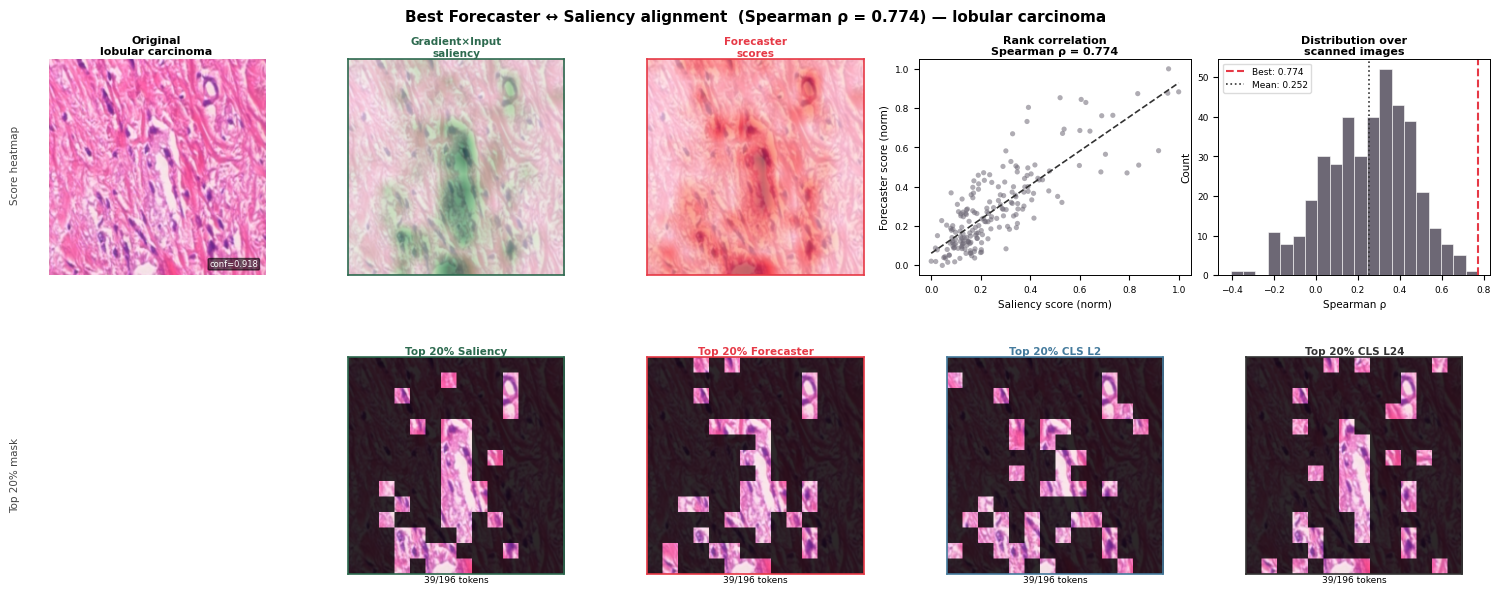

Saved → results/BREAKHIS/method_viz/fig_best_saliency_alignment.pdf


In [101]:
# ── Fig. D: plot della migliore corrispondenza ────────────────────────────
bs = best_sal
img_D   = bs["img_np"]
fc_D    = bs["fc_scores"]
sal_D   = bs["sal"]
cls2_D  = bs["cls2"]
last_D  = bs["last_attn"]

COLOR_FC  = CFG["color_fc"]
COLOR_CLS = CFG["color_cls"]
COLOR_SAL = CFG["color_sal"]

# Layout 2 righe × 5 colonne
# Riga 0: original | saliency heatmap | forecaster heatmap | scatter sal vs fc | distribuzione score
# Riga 1:    —     | top-20% saliency | top-20% forecaster | top-20% CLS L2   | top-20% CLS L24
fig_D = plt.figure(figsize=(15, 6.2))
gs_D  = gridspec.GridSpec(
    2, 5, figure=fig_D,
    wspace=0.10, hspace=0.38,
    left=0.01, right=0.99, top=0.89, bottom=0.06
)

KR_D = 0.2

# ── Riga 0 ───────────────────────────────────────────────────────────────

# [0,0] Originale
ax_d00 = fig_D.add_subplot(gs_D[0, 0])
ax_d00.imshow(img_D, interpolation="bilinear")
ax_d00.set_title(
    f"Original\n{CLASS_NAMES[bs['label']].replace('_',' ')}",
    fontsize=8, fontweight="bold", pad=3)
ax_d00.set_xticks([]); ax_d00.set_yticks([])
for sp in ax_d00.spines.values(): sp.set_visible(False)
ax_d00.text(0.97, 0.03, f"conf={bs['conf']:.3f}",
            transform=ax_d00.transAxes, fontsize=6, color="white",
            ha="right", va="bottom",
            bbox=dict(boxstyle="round,pad=0.15", fc="black", alpha=0.55))

# [0,1] Saliency heatmap
ax_d01 = fig_D.add_subplot(gs_D[0, 1])
ax_heatmap(ax_d01, img_D, sal_D,
           "Gradient×Input\nsaliency", COLOR_SAL, cmap="Greens")

# [0,2] Forecaster heatmap
ax_d02 = fig_D.add_subplot(gs_D[0, 2])
ax_heatmap(ax_d02, img_D, fc_D,
           "Forecaster\nscores", COLOR_FC, cmap="Reds")

# [0,3] Scatter plot: sal_D vs fc_D (196 punti)
ax_d03 = fig_D.add_subplot(gs_D[0, 3])
sal_n = (sal_D - sal_D.min()) / (sal_D.max() - sal_D.min() + 1e-8)
fc_n  = (fc_D  - fc_D.min())  / (fc_D.max()  - fc_D.min()  + 1e-8)
ax_d03.scatter(sal_n.numpy(), fc_n.numpy(),
               alpha=0.55, s=14, c="#6d6875", edgecolors="none")
# Fit lineare per visualizzazione
z = np.polyfit(sal_n.numpy(), fc_n.numpy(), 1)
xline = np.linspace(0, 1, 100)
ax_d03.plot(xline, np.polyval(z, xline), color="#333", lw=1.2, ls="--")
ax_d03.set_xlabel("Saliency score (norm)", fontsize=7.5)
ax_d03.set_ylabel("Forecaster score (norm)", fontsize=7.5)
ax_d03.set_title(
    f"Rank correlation\nSpearman ρ = {bs['spearman']:.3f}",
    fontsize=8, fontweight="bold", pad=3)
ax_d03.tick_params(labelsize=6.5)
for sp in ax_d03.spines.values(): sp.set_linewidth(0.7)

# [0,4] Distribuzione Spearman su tutti i campioni scansionati
ax_d04 = fig_D.add_subplot(gs_D[0, 4])
all_rho = [r["spearman"] for r in sal_records]
ax_d04.hist(all_rho, bins=20, color="#6d6875", edgecolor="white", linewidth=0.4)
ax_d04.axvline(bs["spearman"], color=COLOR_FC, lw=1.5, ls="--",
               label=f"Best: {bs['spearman']:.3f}")
ax_d04.axvline(float(np.mean(all_rho)), color="#333", lw=1.2, ls=":",
               label=f"Mean: {float(np.mean(all_rho)):.3f}")
ax_d04.set_xlabel("Spearman ρ", fontsize=7.5)
ax_d04.set_ylabel("Count", fontsize=7.5)
ax_d04.set_title("Distribution over\nscanned images",
                  fontsize=8, fontweight="bold", pad=3)
ax_d04.legend(fontsize=6.5, framealpha=0.7)
ax_d04.tick_params(labelsize=6.5)
for sp in ax_d04.spines.values(): sp.set_linewidth(0.7)

# ── Riga 1: maschere binarie top-KR_D ────────────────────────────────────
fig_D.add_subplot(gs_D[1, 0]).set_visible(False)

ax_d11 = fig_D.add_subplot(gs_D[1, 1])
ax_pruned(ax_d11, img_D, scores_to_mask(sal_D, KR_D),
          f"Top {KR_D:.0%} Saliency", COLOR_SAL)

ax_d12 = fig_D.add_subplot(gs_D[1, 2])
ax_pruned(ax_d12, img_D, scores_to_mask(fc_D, KR_D),
          f"Top {KR_D:.0%} Forecaster", COLOR_FC)

ax_d13 = fig_D.add_subplot(gs_D[1, 3])
ax_pruned(ax_d13, img_D, scores_to_mask(cls2_D, KR_D),
          f"Top {KR_D:.0%} CLS L2", COLOR_CLS)

ax_d14 = fig_D.add_subplot(gs_D[1, 4])
ax_pruned(ax_d14, img_D, scores_to_mask(last_D, KR_D),
          f"Top {KR_D:.0%} CLS L24", "#333333")

# Etichette riga
fig_D.text(0.003, 0.72, "Score heatmap",
           fontsize=7.5, va="center", rotation=90, color="#444")
fig_D.text(0.003, 0.22, f"Top {KR_D:.0%} mask",
           fontsize=7.5, va="center", rotation=90, color="#444")

fig_D.suptitle(
    f"Best Forecaster ↔ Saliency alignment  "
    f"(Spearman ρ = {bs['spearman']:.3f}) — "
    f"{CLASS_NAMES[bs['label']].replace('_', ' ')}",
    fontsize=11, fontweight="bold", y=0.97
)

out_D = CFG["out_dir"] / "fig_best_saliency_alignment.pdf"
fig_D.savefig(out_D, dpi=200, bbox_inches="tight")
fig_D.savefig(str(out_D).replace(".pdf", ".png"), dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {out_D}")

Saved → results/BREAKHIS/method_viz/fig_top3_alignment_publication.pdf


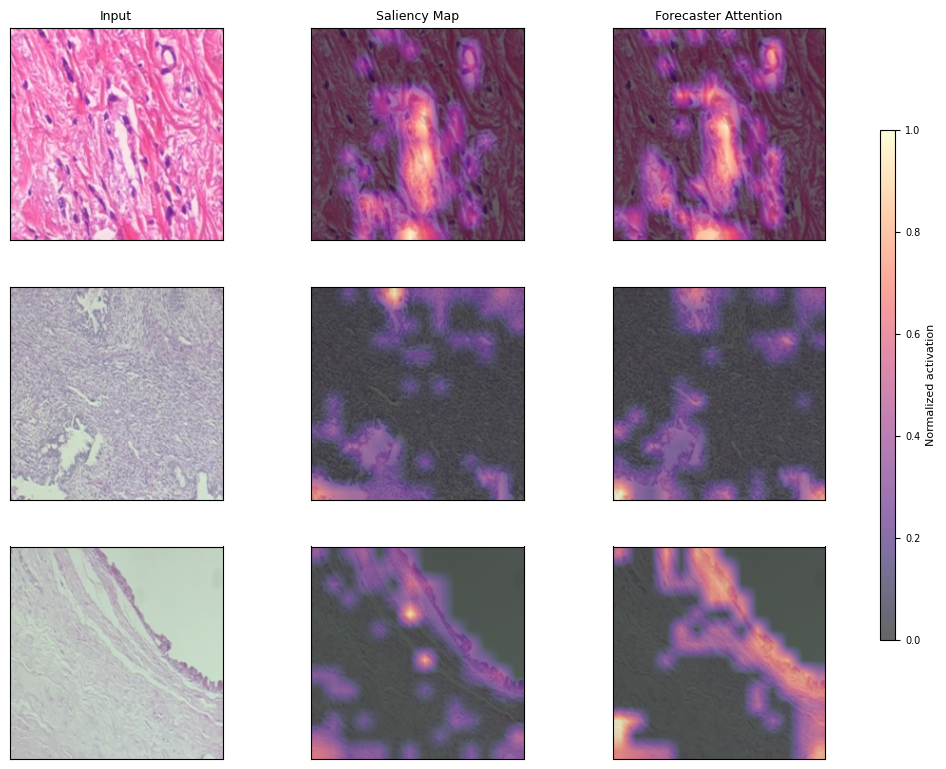

In [102]:
# ── Layout publication-ready ─────────────────────────────────────────────

fig_E = plt.figure(figsize=(10.5, 8.5))
gs_E  = gridspec.GridSpec(
    3, 3, figure=fig_E,
    wspace=0.08, hspace=0.22,
    left=0.06, right=0.90, top=0.92, bottom=0.06
)

col_titles = ["Input", "Saliency Map", "Forecaster Attention"]

def normalize_map(x):
    x = x - x.min()
    x = x / (x.max() + 1e-8)
    return x

def upsample_map(heat):
    from PIL import Image as _PIL
    heat_up = np.array(
        _PIL.fromarray((heat * 255).astype(np.uint8)).resize(
            (CFG["img_size"], CFG["img_size"]),
            resample=_PIL.BILINEAR)
    ) / 255.0
    return heat_up

for row, d in enumerate(top3_data):

    img    = d["img_np"]
    fc_s   = d["fc_scores"]
    sal_s  = d["sal"]
    rho    = d["spearman"]
    cls_nm = CLASS_NAMES[d["label"]].replace("_", " ")

    for col in range(3):

        ax = fig_E.add_subplot(gs_E[row, col])
        ax.set_xticks([])
        ax.set_yticks([])

        if col == 0:
            ax.imshow(img)
           

        else:
            scores = sal_s if col == 1 else fc_s
            heat = scores.reshape(H_G, W_G).numpy()
            heat = normalize_map(heat)

            # 🔬 threshold soft (top 30%)
            thresh = np.quantile(heat, 0.70)
            heat = np.where(heat >= thresh, heat, 0)

            heat = upsample_map(heat)

            ax.imshow(img)
            im = ax.imshow(
                heat,
                cmap="magma",
                alpha=0.6,
                vmin=0,
                vmax=1
            )

        if row == 0:
            ax.set_title(col_titles[col], fontsize=9)

# ── Colorbar scientifica ────────────────────────────────────────────────
cax = fig_E.add_axes([0.92, 0.20, 0.015, 0.60])
cb = fig_E.colorbar(im, cax=cax)
cb.set_label("Normalized activation", fontsize=8)
cb.ax.tick_params(labelsize=7)



out_pdf = CFG["out_dir"] / "fig_top3_alignment_publication.pdf"

fig_E.savefig(
    out_pdf,
    format="pdf",
    bbox_inches="tight"
)

print(f"Saved → {out_pdf}")

plt.show()

---
## Fig. F — Correlazione Saliency ↔ CLS Attention per layer

Per ogni layer $l \in \{0,\ldots,23\}$ del classificatore **baseline** (senza pruning)
calcoliamo la **Spearman rank correlation** tra:
- `sal` — Gradient×Input saliency (196 patch scores) calcolata sul modello baseline
- `attn[l]` — media delle attenzioni CLS→patch su tutte le teste al layer $l$

Il plot mostra media ± std su un campione stratificato del test set.
La linea verticale indica il **layer di pruning** ($k=2$);
la linea orizzontale tratteggiata indica la correlazione media
**Forecaster ↔ Saliency** (da Fig. D) come riferimento.

**Interpretazione attesa**: la correlazione cresce con la profondità — i layer finali
hanno attenzione più semanticamente allineata alla saliency rispetto ai layer iniziali.
Se il forecaster supera l'attenzione al layer 2, significa che ha appreso
un segnale di importanza più ricco di quello disponibile localmente.

In [103]:
# ── Carica il classificatore BASELINE (no pruning) ────────────────────────
# Necessario per calcolare saliency e attenzioni non influenzate dal fine-tuning
# con pruning. Le attenzioni del modello pruned-ft potrebbero essere distorte
# dalla distribuzione di sequenze corte vista durante il training.
print("Loading baseline classifier (no pruning)...")
clf_base = freeze(load_ckpt(UNILoRAClassifier(N_CLASSES).to(device),
                             CFG["ckpt_classifier"], strict=False))
vit_base = clf_base.backbone.model
print(f"Baseline ViT: {len(vit_base.blocks)} blocks")


def extract_all_layers_attn(img_norm_t, vit_model):
    """
    Esegue il forward del ViT e restituisce la CLS→patch attention
    (media sulle teste) per ciascuno dei 24 layer.
    Ritorna: list of (196,) tensors, uno per layer.
    """
    x = img_norm_t.to(device)
    B = 1
    x = vit_model.patch_embed(x)
    x = vit_model._pos_embed(x)
    x = vit_model.patch_drop(x)
    x = vit_model.norm_pre(x)

    layer_attns = []
    for blk in vit_model.blocks:
        N, C = x.shape[1], x.shape[2]
        x_n1 = blk.norm1(x)   # (1, N, D)
        qkv  = blk.attn.qkv(x_n1).reshape(B, N, 3, blk.attn.num_heads, -1).permute(2,0,3,1,4)
        q, k, _ = qkv.unbind(0)
        q, k = blk.attn.q_norm(q), blk.attn.k_norm(k)
        attn = (q @ k.transpose(-2,-1) * blk.attn.scale).softmax(-1)  # (1,H,N,N)
        # CLS→patch: [:, :, 0, 1:] → media teste → (196,)
        cls_attn = attn[0, :, 0, 1:].mean(0).cpu()   # (196,)
        layer_attns.append(cls_attn)
        x = blk(x)   # forward completo del blocco

    return layer_attns   # list of 24 tensors (196,)


def compute_saliency_baseline(img_norm_t, target_class, vit_model, head):
    """Gradient×Input sul modello baseline — patch scores (196,)."""
    inp = img_norm_t.to(device).requires_grad_(True)

    # Forward manuale per usare vit_model + head separati
    x = vit_model.patch_embed(inp)
    x = vit_model._pos_embed(x)
    x = vit_model.patch_drop(x)
    x = vit_model.norm_pre(x)
    for blk in vit_model.blocks:
        x = blk(x)
    x = vit_model.norm(x)
    logits = head(x[:, 0])
    logits[0, target_class].backward()

    grad  = inp.grad.detach().cpu()
    inp_d = inp.detach().cpu()
    gi    = (grad * inp_d).abs().sum(dim=1)[0]   # (224,224)

    P, H_g, W_g = CFG["patch_size"], CFG["grid_h"], CFG["grid_w"]
    patch_scores = torch.zeros(H_g * W_g)
    for r in range(H_g):
        for c in range(W_g):
            patch_scores[r*W_g+c] = gi[r*P:(r+1)*P, c*P:(c+1)*P].mean()
    inp.grad = None
    return patch_scores   # (196,)


# ── Scan stratificato ─────────────────────────────────────────────────────
from scipy.stats import spearmanr as _spearmanr
import random as _random

N_LAYERS       = len(vit_base.blocks)   # 24
N_SCAN_CLS     = 50                     # campioni per classe

_random.seed(42)
_class_idx = {c: [] for c in range(N_CLASSES)}
for i in range(len(test_ds)):
    _class_idx[test_ds.labels[i]].append(i)
scan_idx_F = []
for c in range(N_CLASSES):
    pool = _class_idx[c]
    scan_idx_F.extend(_random.sample(pool, min(N_SCAN_CLS, len(pool))))

print(f"Scanning {len(scan_idx_F)} images ({N_SCAN_CLS}/class) across {N_LAYERS} layers...")
print("Each image: 1 no-grad forward (attn) + 1 backward (saliency).")

# rho_matrix: shape (N_images, N_LAYERS)
rho_rows = []   # one list of 24 floats per image
fc_rhos  = []   # Spearman(forecaster, saliency_baseline) per confronto

for p in clf_base.parameters(): p.requires_grad_(True)
clf_base.eval()

for idx in tqdm(scan_idx_F):
    lbl = test_ds.labels[idx]
    img_n, _ = test_ds[idx]
    img_n_t  = img_n.unsqueeze(0)

    # Classificazione baseline
    with torch.no_grad():
        logits_b = clf_base(img_n_t.to(device))
    pred_b = logits_b.argmax(-1).item()
    if pred_b != lbl:
        continue   # salta predizioni errate

    # 1) Attenzione per tutti i layer (no grad)
    with torch.no_grad():
        layer_attns = extract_all_layers_attn(img_n_t, vit_base)  # list[24] di (196,)

    # 2) Saliency baseline (backward)
    sal = compute_saliency_baseline(img_n_t, lbl, vit_base, clf_base.head)

    # 3) Spearman per ogni layer
    rhos = [float(_spearmanr(layer_attns[l].numpy(), sal.numpy()).statistic)
            for l in range(N_LAYERS)]
    rho_rows.append(rhos)

    # 4) Spearman forecaster vs saliency_baseline
    with torch.no_grad():
        out_fc = extract_all(img_n_t)   # usa clf (pruned_ft) + forecaster
    fc_rho = float(_spearmanr(out_fc["fc_scores"].numpy(), sal.numpy()).statistic)
    fc_rhos.append(fc_rho)

for p in clf_base.parameters(): p.requires_grad_(False)

import numpy as _np
rho_matrix = _np.array(rho_rows)   # (N_valid, 24)
fc_rho_arr = _np.array(fc_rhos)

print(f"\nValid samples: {rho_matrix.shape[0]}")
print(f"Rho matrix shape: {rho_matrix.shape}")
print(f"Forecaster vs Saliency — mean ρ = {fc_rho_arr.mean():.4f} ± {fc_rho_arr.std():.4f}")
print("\nPer-layer mean ρ:")
for l in range(N_LAYERS):
    star = " ← pruning layer" if l == CFG["prune_layer"] else ""
    print(f"  Layer {l:2d}: {rho_matrix[:,l].mean():.4f} ± {rho_matrix[:,l].std():.4f}{star}")

Loading baseline classifier (no pruning)...
Baseline ViT: 24 blocks
Scanning 400 images (50/class) across 24 layers...
Each image: 1 no-grad forward (attn) + 1 backward (saliency).


  0%|          | 0/400 [00:00<?, ?it/s]


Valid samples: 399
Rho matrix shape: (399, 24)
Forecaster vs Saliency — mean ρ = 0.1787 ± 0.2333

Per-layer mean ρ:
  Layer  0: 0.0642 ± 0.1106
  Layer  1: 0.1571 ± 0.1494
  Layer  2: 0.1494 ± 0.1890 ← pruning layer
  Layer  3: 0.2477 ± 0.1659
  Layer  4: 0.2376 ± 0.2059
  Layer  5: 0.1780 ± 0.2353
  Layer  6: 0.1997 ± 0.2275
  Layer  7: 0.2364 ± 0.2198
  Layer  8: 0.2560 ± 0.2220
  Layer  9: 0.3242 ± 0.2072
  Layer 10: 0.3168 ± 0.2360
  Layer 11: 0.3826 ± 0.2127
  Layer 12: 0.4481 ± 0.1982
  Layer 13: 0.3818 ± 0.2293
  Layer 14: 0.3609 ± 0.2374
  Layer 15: 0.3670 ± 0.2402
  Layer 16: 0.3357 ± 0.2552
  Layer 17: 0.3753 ± 0.2480
  Layer 18: 0.4188 ± 0.2247
  Layer 19: 0.3933 ± 0.2194
  Layer 20: 0.3667 ± 0.2218
  Layer 21: 0.3527 ± 0.2164
  Layer 22: 0.3318 ± 0.2285
  Layer 23: 0.3350 ± 0.2194


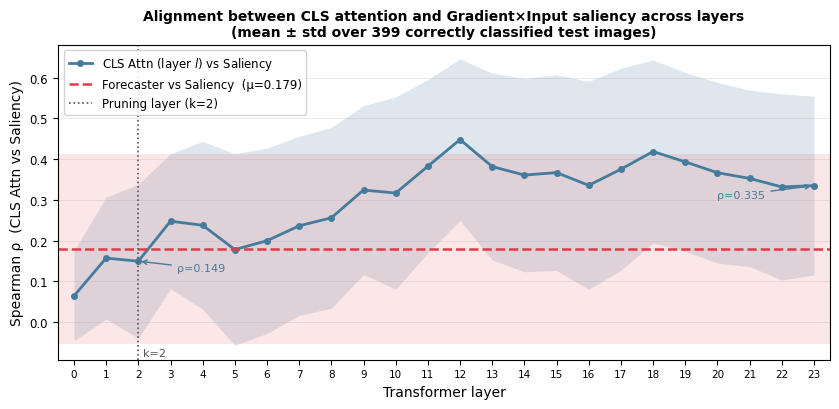

Saved → results/BREAKHIS/method_viz/fig_layerwise_correlation.pdf
clf_base unloaded from GPU.


In [104]:
# ── Fig. F: Spearman ρ (Saliency ↔ CLS Attn) per layer ──────────────────
import numpy as _np2

layers     = _np2.arange(N_LAYERS)
mean_rho   = rho_matrix.mean(axis=0)     # (24,)
std_rho    = rho_matrix.std(axis=0)      # (24,)
fc_mean    = fc_rho_arr.mean()
fc_std     = fc_rho_arr.std()

COLOR_FC   = CFG["color_fc"]
COLOR_CLS  = CFG["color_cls"]
COLOR_SAL  = CFG["color_sal"]
PRUNE_L    = CFG["prune_layer"]   # 2

fig_F, ax_F = plt.subplots(figsize=(8.5, 4.2))

# Banda ± std CLS attention per layer
ax_F.fill_between(layers,
                  mean_rho - std_rho,
                  mean_rho + std_rho,
                  alpha=0.18, color=COLOR_CLS, linewidth=0)
ax_F.plot(layers, mean_rho,
          color=COLOR_CLS, linewidth=2.0, marker="o", markersize=4,
          label="CLS Attn (layer $l$) vs Saliency")

# Linea orizzontale: Forecaster vs Saliency (media ± std)
ax_F.axhline(fc_mean, color=COLOR_FC, linewidth=1.8, linestyle="--",
             label=f"Forecaster vs Saliency  (μ={fc_mean:.3f})")
ax_F.axhspan(fc_mean - fc_std, fc_mean + fc_std,
             alpha=0.12, color=COLOR_FC, linewidth=0)

# Linea verticale: pruning layer
ax_F.axvline(PRUNE_L, color="#555", linewidth=1.2, linestyle=":",
             label=f"Pruning layer (k={PRUNE_L})")
ax_F.text(PRUNE_L + 0.15, ax_F.get_ylim()[0] + 0.005,
          f"k={PRUNE_L}", fontsize=8, color="#555", va="bottom")

# Annotazione sul punto del pruning layer
ax_F.annotate(
    f"ρ={mean_rho[PRUNE_L]:.3f}",
    xy=(PRUNE_L, mean_rho[PRUNE_L]),
    xytext=(PRUNE_L + 1.2, mean_rho[PRUNE_L] - 0.025),
    fontsize=8, color=COLOR_CLS,
    arrowprops=dict(arrowstyle="->", color=COLOR_CLS, lw=1.0)
)

# Annotazione sul punto dell'ultimo layer
ax_F.annotate(
    f"ρ={mean_rho[-1]:.3f}",
    xy=(N_LAYERS-1, mean_rho[-1]),
    xytext=(N_LAYERS-4, mean_rho[-1] - 0.030),
    fontsize=8, color=COLOR_CLS,
    arrowprops=dict(arrowstyle="->", color=COLOR_CLS, lw=1.0)
)

ax_F.set_xlabel("Transformer layer", fontsize=10)
ax_F.set_ylabel("Spearman ρ  (CLS Attn vs Saliency)", fontsize=10)
ax_F.set_title(
    "Alignment between CLS attention and Gradient×Input saliency across layers\n"
    f"(mean ± std over {rho_matrix.shape[0]} correctly classified test images)",
    fontsize=10, fontweight="bold"
)
ax_F.set_xticks(layers)
ax_F.set_xticklabels([str(l) for l in layers], fontsize=7.5)
ax_F.tick_params(axis="y", labelsize=8.5)
ax_F.legend(fontsize=8.5, framealpha=0.85, loc="upper left")
ax_F.grid(axis="y", linewidth=0.5, alpha=0.4)
ax_F.set_xlim(-0.5, N_LAYERS - 0.5)

plt.tight_layout()

out_F = CFG["out_dir"] / "fig_layerwise_correlation.pdf"
fig_F.savefig(out_F, dpi=200, bbox_inches="tight")
fig_F.savefig(str(out_F).replace(".pdf", ".png"), dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {out_F}")

# Unload baseline model
clf_base.cpu()
torch.cuda.empty_cache(); gc.collect()
print("clf_base unloaded from GPU.")

In [105]:
# clf.cpu(); forecaster.cpu()
# torch.cuda.empty_cache(); gc.collect()
# print("GPU liberata.")
# print("\nFile generati:")
# for f in sorted(CFG["out_dir"].glob("fig_*.p*")):
#     print(f"  {f}")